<a href="https://colab.research.google.com/github/eiyu18/pcvk/blob/main/week5_10_EiyuAzizulyEfendi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Eiyu Azizuly Efendi'
NIM  = '244107020181'
N     = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Eiyu Azizuly Efendi
NIM    : 244107020181 | N = 181
bins   : 16
clip   : 1.5
tile   : 3
L      : 4
WAKTU  : 2026-09-30 18:57:40 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : ab3efe7533652051


E-1 PERCOBAAN HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

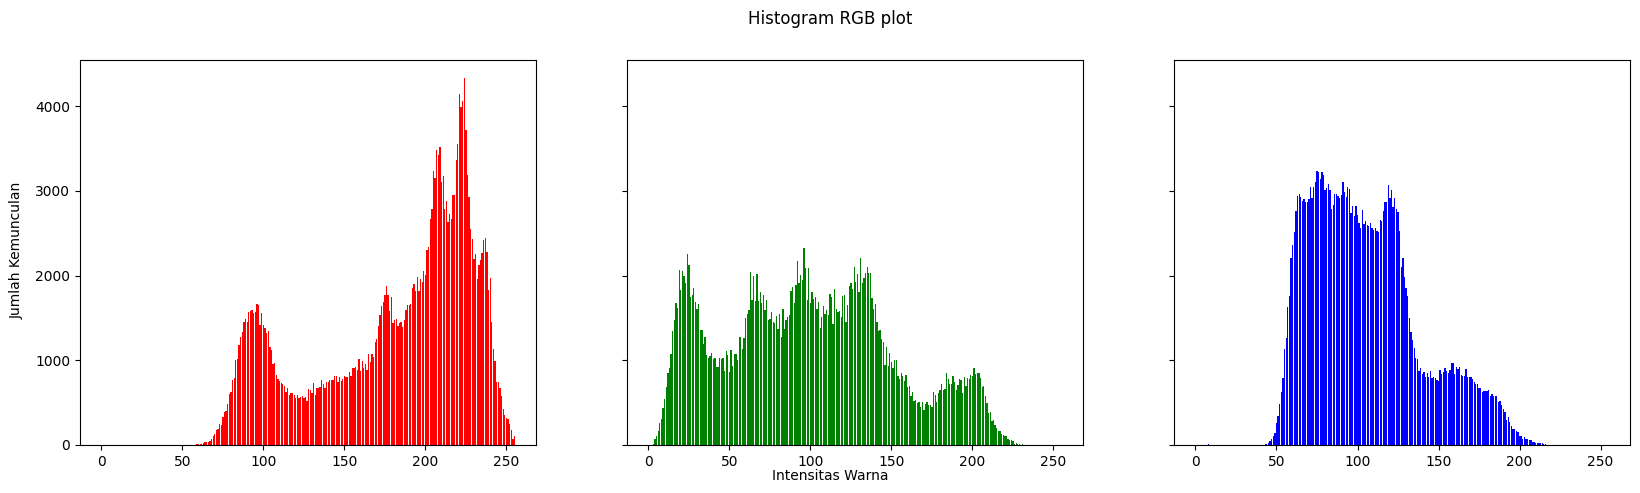

In [5]:
img = cv.imread('/content/sample_data/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0, width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig. suptitle('Histogram RGB plot')
fig. text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig. text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs [1] .bar(names, green, color='green')
axs [2] .bar(names, blue, color='blue')

E-2 PERCOBAAN HISTOGRAM EQUALIZATION

/tmp/ipykernel_2565/3224861608.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,0].hist(gray.ravel(), 256, (0,256), color='gray'); axs[1,0].set_title('Histogram asli')
/tmp/ipykernel_2565/3224861608.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,1].hist(he.ravel(),   256, (0,256), color='gray'); axs[1,1].set_title('Histogram HE')


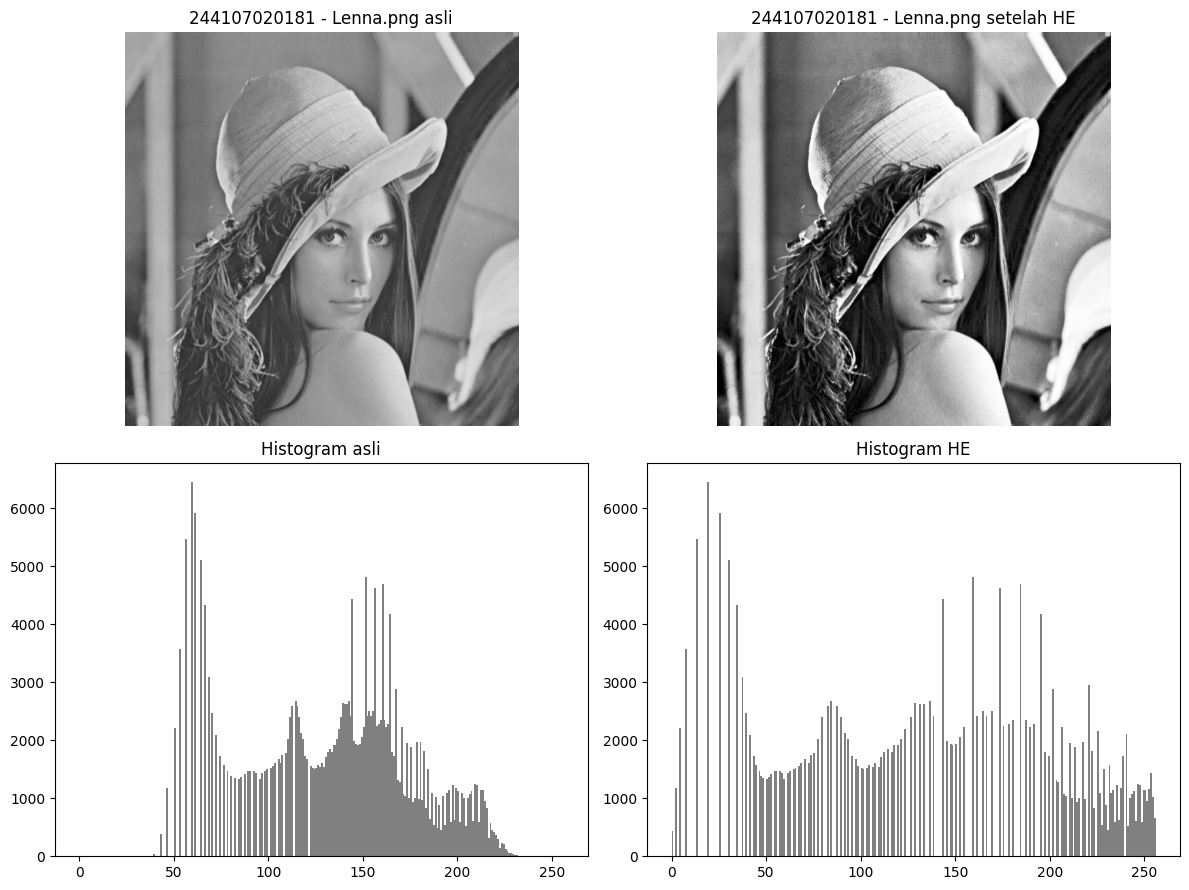

Lenna.png | selisih maks manual vs equalizeHist = 1


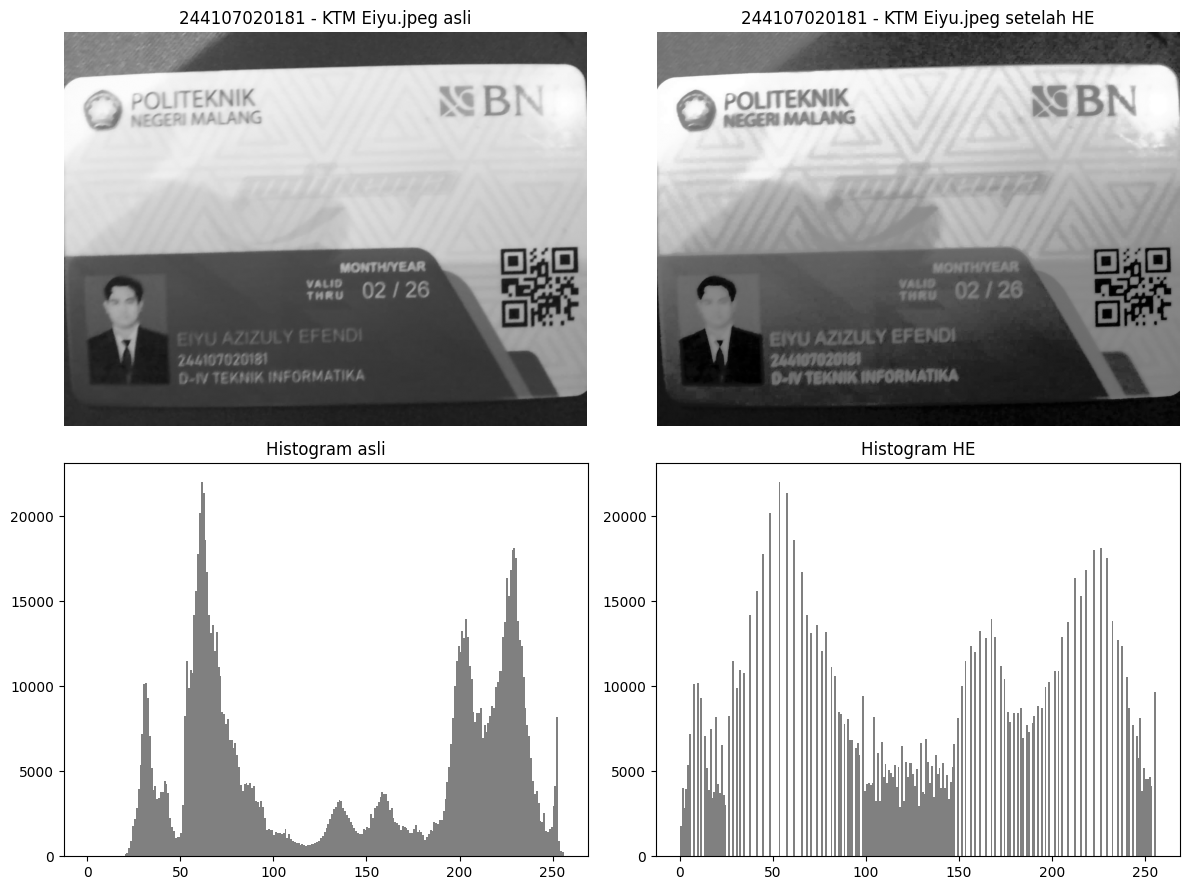

KTM Eiyu.jpeg | selisih maks manual vs equalizeHist = 0


In [8]:
def he_manual(gray):
    h   = np.bincount(gray.ravel(), minlength=256)
    cdf = np.cumsum(h)
    lut = np.round(cdf * 255 / gray.size).astype(np.uint8)
    return lut[gray]

def tampil_he(gray, judul):
    he = he_manual(gray)
    fig, axs = plt.subplots(2, 2, figsize=(12, 9))
    axs[0,0].imshow(gray, cmap='gray', vmin=0, vmax=255); axs[0,0].set_title(NIM + ' - ' + judul + ' asli')
    axs[0,1].imshow(he,   cmap='gray', vmin=0, vmax=255); axs[0,1].set_title(NIM + ' - ' + judul + ' setelah HE')
    axs[1,0].hist(gray.ravel(), 256, (0,256), color='gray'); axs[1,0].set_title('Histogram asli')
    axs[1,1].hist(he.ravel(),   256, (0,256), color='gray'); axs[1,1].set_title('Histogram HE')
    for a in axs.ravel()[:2]: a.axis('off')
    plt.tight_layout(); plt.show()

    cvhe = cv.equalizeHist(gray)
    print(judul, '| selisih maks manual vs equalizeHist =', np.abs(he.astype(int) - cvhe.astype(int)).max())
    return he, cvhe

he_lena, _ = tampil_he(cv.imread('/content/sample_data/Lenna.png', cv.IMREAD_GRAYSCALE), 'Lenna.png')
he_ktm, cvhe_ktm = tampil_he(cv.imread('/content/drive/MyDrive/pcvk/Gambar/KTM_Eiyu.jpeg', cv.IMREAD_GRAYSCALE), 'KTM Eiyu.jpeg')